In [ ]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r"C:\Users\DELL\Desktop\bank_transactions.csv")
data.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/1994,F,JAMSHEDPUR,17819.05,2/8/2016,143207,25.0
1,T2,C2142763,4/4/1957,M,JHAJJAR,2270.69,2/8/2016,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/2016,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/2016,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/2016,181156,1762.5


CHECKING MISSING DATA

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  object 
 1   CustomerID               1048567 non-null  object 
 2   CustomerDOB              1045170 non-null  object 
 3   CustGender               1047467 non-null  object 
 4   CustLocation             1048416 non-null  object 
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  object 
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 72.0+ MB


In [4]:
dataset = data.isna().sum()
print("Missing values in each column:\n", dataset)

Missing values in each column:
 TransactionID                 0
CustomerID                    0
CustomerDOB                3397
CustGender                 1100
CustLocation                151
CustAccountBalance         2369
TransactionDate               0
TransactionTime               0
TransactionAmount (INR)       0
dtype: int64


In [5]:
dataset = data.dropna(subset=['CustLocation', 'CustGender'], inplace=True) 
dataset

In [6]:
data.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/1994,F,JAMSHEDPUR,17819.05,2/8/2016,143207,25.0
1,T2,C2142763,4/4/1957,M,JHAJJAR,2270.69,2/8/2016,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/2016,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/2016,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/2016,181156,1762.5


FILL MISSING VALUES

In [7]:
data['CustAccountBalance'] = data['CustAccountBalance'].fillna(data['CustAccountBalance'].mean())
data.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/1994,F,JAMSHEDPUR,17819.05,2/8/2016,143207,25.0
1,T2,C2142763,4/4/1957,M,JHAJJAR,2270.69,2/8/2016,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/2016,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/2016,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/2016,181156,1762.5


In [8]:
data['CustomerDOB'] = pd.to_datetime(data['CustomerDOB'], errors='coerce')

# Get the mode (most frequent value)
mode_date = data['CustomerDOB'].mode()[0]

# Fill missing values with the mode
data['CustomerDOB'] = data['CustomerDOB'].fillna(mode_date)
data.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,1994-10-01,F,JAMSHEDPUR,17819.05,2/8/2016,143207,25.0
1,T2,C2142763,1957-04-04,M,JHAJJAR,2270.69,2/8/2016,141858,27999.0
2,T3,C4417068,1800-01-01,F,MUMBAI,17874.44,2/8/2016,142712,459.0
3,T4,C5342380,1800-01-01,F,MUMBAI,866503.21,2/8/2016,142714,2060.0
4,T5,C9031234,1800-01-01,F,NAVI MUMBAI,6714.43,2/8/2016,181156,1762.5


DROPPING COLUMNS

In [9]:
print(data.columns.tolist())

['TransactionID', 'CustomerID', 'CustomerDOB', 'CustGender', 'CustLocation', 'CustAccountBalance', 'TransactionDate', 'TransactionTime', 'TransactionAmount (INR)']


In [10]:
data = data.drop(['TransactionID', 'CustomerID'], axis=1)

In [11]:
data.head()

,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,1994-10-01,F,JAMSHEDPUR,17819.05,2/8/2016,143207,25.0
1,1957-04-04,M,JHAJJAR,2270.69,2/8/2016,141858,27999.0
2,1800-01-01,F,MUMBAI,17874.44,2/8/2016,142712,459.0
3,1800-01-01,F,MUMBAI,866503.21,2/8/2016,142714,2060.0
4,1800-01-01,F,NAVI MUMBAI,6714.43,2/8/2016,181156,1762.5


In [12]:
dataset = data.isna().sum()
print("Missing values in each column:\n", dataset)

Missing values in each column:
 CustomerDOB                0
CustGender                 0
CustLocation               0
CustAccountBalance         0
TransactionDate            0
TransactionTime            0
TransactionAmount (INR)    0
dtype: int64


In [13]:
data.head()

,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,1994-10-01,F,JAMSHEDPUR,17819.05,2/8/2016,143207,25.0
1,1957-04-04,M,JHAJJAR,2270.69,2/8/2016,141858,27999.0
2,1800-01-01,F,MUMBAI,17874.44,2/8/2016,142712,459.0
3,1800-01-01,F,MUMBAI,866503.21,2/8/2016,142714,2060.0
4,1800-01-01,F,NAVI MUMBAI,6714.43,2/8/2016,181156,1762.5


HANDLIND CustomerDOB CONVERT OBJECT TO DATETIME TO AGE

In [14]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1047316 entries, 0 to 1048566
Data columns (total 7 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   CustomerDOB              1047316 non-null  datetime64[ns]
 1   CustGender               1047316 non-null  object        
 2   CustLocation             1047316 non-null  object        
 3   CustAccountBalance       1047316 non-null  float64       
 4   TransactionDate          1047316 non-null  object        
 5   TransactionTime          1047316 non-null  int64         
 6   TransactionAmount (INR)  1047316 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 63.9+ MB


In [15]:
# Convert to datetime
data['CustomerDOB'] = pd.to_datetime(data['CustomerDOB'], format="%Y-%m-%d")

# Calculate Age
today = pd.to_datetime('today')
data['Age'] = (today - data['CustomerDOB']).dt.days // 365

# Drop CustomerDOB  for clustering
data = data.drop(columns=['CustomerDOB'])

data.head()

,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
0,F,JAMSHEDPUR,17819.05,2/8/2016,143207,25.0,30
1,M,JHAJJAR,2270.69,2/8/2016,141858,27999.0,68
2,F,MUMBAI,17874.44,2/8/2016,142712,459.0,225
3,F,MUMBAI,866503.21,2/8/2016,142714,2060.0,225
4,F,NAVI MUMBAI,6714.43,2/8/2016,181156,1762.5,225


HANDLING TransactionDate CONVERT OBJECT TO DATETIME AND EXTRACT (two-digit years like "21/10/16", which don’t match the strict format "%d/%m/%Y" expecting a four-digit year "21/10/2016)

In [16]:
data['TransactionDate'] = pd.to_datetime(data['TransactionDate'], dayfirst=True, infer_datetime_format=True, errors='coerce')

print(data.dtypes)

CustGender                         object
CustLocation                       object
CustAccountBalance                float64
TransactionDate            datetime64[ns]
TransactionTime                     int64
TransactionAmount (INR)           float64
Age                                 int64
dtype: object


C:\Users\DELL\AppData\Local\Temp\ipykernel_2268\813685827.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data['TransactionDate'] = pd.to_datetime(data['TransactionDate'], dayfirst=True, infer_datetime_format=True, errors='coerce')


In [17]:
dataset = data.isna().sum()
print("Missing values in each column:\n", dataset)

Missing values in each column:
 CustGender                      0
CustLocation                    0
CustAccountBalance              0
TransactionDate            506047
TransactionTime                 0
TransactionAmount (INR)         0
Age                             0
dtype: int64


In [18]:
data.head()

,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
0,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0,30
1,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0,68
2,F,MUMBAI,17874.44,2016-08-02,142712,459.0,225
3,F,MUMBAI,866503.21,2016-08-02,142714,2060.0,225
4,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5,225


FILL TransactionDate WITH FREQUENT MODE

In [19]:
# Find the mode (most frequent date)
mode_date = data['TransactionDate'].mode()[0]

# Fill missing values with mode
data['TransactionDate'].fillna(mode_date, inplace=True)
data.head()

C:\Users\DELL\AppData\Local\Temp\ipykernel_2268\4113210245.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['TransactionDate'].fillna(mode_date, inplace=True)


,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
0,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0,30
1,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0,68
2,F,MUMBAI,17874.44,2016-08-02,142712,459.0,225
3,F,MUMBAI,866503.21,2016-08-02,142714,2060.0,225
4,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5,225


In [20]:
dataset = data.isna().sum()
print("Missing values in each column:\n", dataset)

Missing values in each column:
 CustGender                 0
CustLocation               0
CustAccountBalance         0
TransactionDate            0
TransactionTime            0
TransactionAmount (INR)    0
Age                        0
dtype: int64


In [21]:
data.head()

,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
0,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0,30
1,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0,68
2,F,MUMBAI,17874.44,2016-08-02,142712,459.0,225
3,F,MUMBAI,866503.21,2016-08-02,142714,2060.0,225
4,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5,225


EXTRACT TransactionDate

In [22]:
# Extract date/time components
data['Year'] = data['TransactionDate'].dt.year
data['Month'] = data['TransactionDate'].dt.month
data['Day'] = data['TransactionDate'].dt.day
data.head()

,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age,Year,Month,Day
0,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0,30,2016,8,2
1,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0,68,2016,8,2
2,F,MUMBAI,17874.44,2016-08-02,142712,459.0,225,2016,8,2
3,F,MUMBAI,866503.21,2016-08-02,142714,2060.0,225,2016,8,2
4,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5,225,2016,8,2


In [23]:
#droping TransactionDate column
data.drop(['TransactionDate'], axis=1, inplace=True)
data.head()

,CustGender,CustLocation,CustAccountBalance,TransactionTime,TransactionAmount (INR),Age,Year,Month,Day
0,F,JAMSHEDPUR,17819.05,143207,25.0,30,2016,8,2
1,M,JHAJJAR,2270.69,141858,27999.0,68,2016,8,2
2,F,MUMBAI,17874.44,142712,459.0,225,2016,8,2
3,F,MUMBAI,866503.21,142714,2060.0,225,2016,8,2
4,F,NAVI MUMBAI,6714.43,181156,1762.5,225,2016,8,2


HANDLING CATEGORICAL VARIABLES (3)

In [24]:
data['CustGender'].unique() 

array(['F', 'M', 'T'], dtype=object)

In [25]:
CustGender_dummies = pd.get_dummies(data['CustGender'], dtype=int, drop_first=True)
CustGender_dummies.head()

,M,T
0,0,0
1,1,0
2,0,0
3,0,0
4,0,0


In [26]:
data = pd.concat([CustGender_dummies, data], axis=1)
data.head()

,M,T,CustGender,CustLocation,CustAccountBalance,TransactionTime,TransactionAmount (INR),Age,Year,Month,Day
0,0,0,F,JAMSHEDPUR,17819.05,143207,25.0,30,2016,8,2
1,1,0,M,JHAJJAR,2270.69,141858,27999.0,68,2016,8,2
2,0,0,F,MUMBAI,17874.44,142712,459.0,225,2016,8,2
3,0,0,F,MUMBAI,866503.21,142714,2060.0,225,2016,8,2
4,0,0,F,NAVI MUMBAI,6714.43,181156,1762.5,225,2016,8,2


In [27]:
data.drop(['CustGender'], axis=1, inplace=True)
data.head()

,M,T,CustLocation,CustAccountBalance,TransactionTime,TransactionAmount (INR),Age,Year,Month,Day
0,0,0,JAMSHEDPUR,17819.05,143207,25.0,30,2016,8,2
1,1,0,JHAJJAR,2270.69,141858,27999.0,68,2016,8,2
2,0,0,MUMBAI,17874.44,142712,459.0,225,2016,8,2
3,0,0,MUMBAI,866503.21,142714,2060.0,225,2016,8,2
4,0,0,NAVI MUMBAI,6714.43,181156,1762.5,225,2016,8,2


HANDLING CustLocation CATEGORICAL VARIABLES

In [28]:
data['CustLocation'].unique() 

array(['JAMSHEDPUR', 'JHAJJAR', 'MUMBAI', ..., 'KARANJIA',
       'NR HERITAGE FRESH HYDERABAD', 'IMPERIA THANE WEST'], dtype=object)

In [29]:
# Define the cities to keep, all others will be grouped as 'OTHERS'
top_cities = ['MUMBAI', 'NEW DELHI']

# Create a new column with grouped values
data['City_Grouped'] = data['CustLocation'].apply(lambda x: x if x in top_cities else 'OTHERS')
data.head()

,M,T,CustLocation,CustAccountBalance,TransactionTime,TransactionAmount (INR),Age,Year,Month,Day,City_Grouped
0,0,0,JAMSHEDPUR,17819.05,143207,25.0,30,2016,8,2,OTHERS
1,1,0,JHAJJAR,2270.69,141858,27999.0,68,2016,8,2,OTHERS
2,0,0,MUMBAI,17874.44,142712,459.0,225,2016,8,2,MUMBAI
3,0,0,MUMBAI,866503.21,142714,2060.0,225,2016,8,2,MUMBAI
4,0,0,NAVI MUMBAI,6714.43,181156,1762.5,225,2016,8,2,OTHERS


In [30]:
City_Grouped_dummies = pd.get_dummies(data['City_Grouped'], dtype=int, drop_first=True)
City_Grouped_dummies.head()

,NEW DELHI,OTHERS
0,0,1
1,0,1
2,0,0
3,0,0
4,0,1


In [31]:
data = pd.concat([City_Grouped_dummies, data], axis=1)
data.head()

,NEW DELHI,OTHERS,M,T,CustLocation,CustAccountBalance,TransactionTime,TransactionAmount (INR),Age,Year,Month,Day,City_Grouped
0,0,1,0,0,JAMSHEDPUR,17819.05,143207,25.0,30,2016,8,2,OTHERS
1,0,1,1,0,JHAJJAR,2270.69,141858,27999.0,68,2016,8,2,OTHERS
2,0,0,0,0,MUMBAI,17874.44,142712,459.0,225,2016,8,2,MUMBAI
3,0,0,0,0,MUMBAI,866503.21,142714,2060.0,225,2016,8,2,MUMBAI
4,0,1,0,0,NAVI MUMBAI,6714.43,181156,1762.5,225,2016,8,2,OTHERS


In [32]:
data = data.drop(['CustLocation', 'City_Grouped'], axis=1)
data.head()

,NEW DELHI,OTHERS,M,T,CustAccountBalance,TransactionTime,TransactionAmount (INR),Age,Year,Month,Day
0,0,1,0,0,17819.05,143207,25.0,30,2016,8,2
1,0,1,1,0,2270.69,141858,27999.0,68,2016,8,2
2,0,0,0,0,17874.44,142712,459.0,225,2016,8,2
3,0,0,0,0,866503.21,142714,2060.0,225,2016,8,2
4,0,1,0,0,6714.43,181156,1762.5,225,2016,8,2


In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1047316 entries, 0 to 1048566
Data columns (total 11 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   NEW DELHI                1047316 non-null  int32  
 1   OTHERS                   1047316 non-null  int32  
 2   M                        1047316 non-null  int32  
 3   T                        1047316 non-null  int32  
 4   CustAccountBalance       1047316 non-null  float64
 5   TransactionTime          1047316 non-null  int64  
 6   TransactionAmount (INR)  1047316 non-null  float64
 7   Age                      1047316 non-null  int64  
 8   Year                     1047316 non-null  int32  
 9   Month                    1047316 non-null  int32  
 10  Day                      1047316 non-null  int32  
dtypes: float64(2), int32(7), int64(2)
memory usage: 67.9 MB


In [34]:
data.head()

,NEW DELHI,OTHERS,M,T,CustAccountBalance,TransactionTime,TransactionAmount (INR),Age,Year,Month,Day
0,0,1,0,0,17819.05,143207,25.0,30,2016,8,2
1,0,1,1,0,2270.69,141858,27999.0,68,2016,8,2
2,0,0,0,0,17874.44,142712,459.0,225,2016,8,2
3,0,0,0,0,866503.21,142714,2060.0,225,2016,8,2
4,0,1,0,0,6714.43,181156,1762.5,225,2016,8,2


STANDARDIZATION

In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() 

In [36]:
data[['CustAccountBalance', 'TransactionTime', 'TransactionAmount (INR)']] = scaler.fit_transform(data[['CustAccountBalance', 'TransactionTime', 'TransactionAmount (INR)']]) 
data.head()

,NEW DELHI,OTHERS,M,T,CustAccountBalance,TransactionTime,TransactionAmount (INR),Age,Year,Month,Day
0,0,1,0,0,-0.115457,-0.270877,-0.235543,30,2016,8,2
1,0,1,1,0,-0.133836,-0.297191,4.018820,68,2016,8,2
2,0,0,0,0,-0.115392,-0.280532,-0.169539,225,2016,8,2
3,0,0,0,0,0.887693,-0.280493,0.073946,225,2016,8,2
4,0,1,0,0,-0.128583,0.469365,0.028701,225,2016,8,2


CREATING A TRAINING SET AND TEST SET
using elbow method to find optimal clusters numbers

In [37]:
import matplotlib.pyplot as plt 

from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
    kmeans.fit(data)
    wcss.append(kmeans.inertia_)

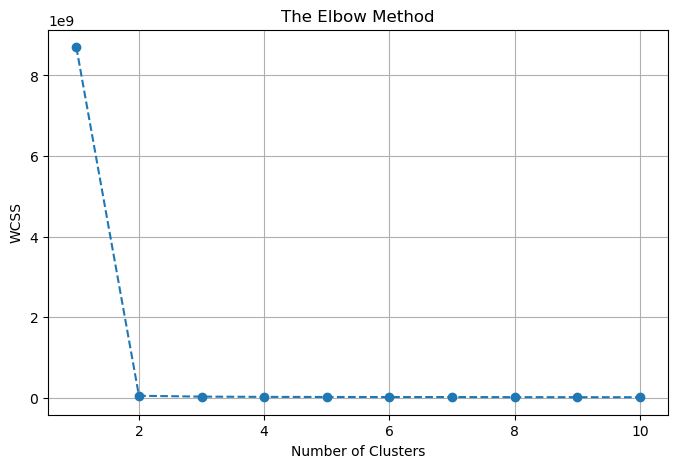

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

Training the K-Means model on the dataset (nber of cluster 2; meaning 0 to 1) 

In [39]:
kmeans = KMeans(n_clusters = 2, init="k-means++", random_state = 42) 

In [40]:
data['Cluster'] = kmeans.fit_predict(data)

c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


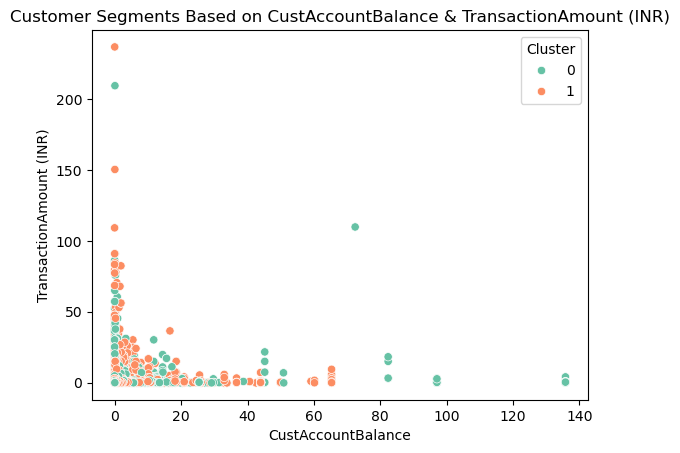

In [41]:
sns.scatterplot(x='CustAccountBalance', y='TransactionAmount (INR)', hue='Cluster', data=data, palette='Set2')
plt.title('Customer Segments Based on CustAccountBalance & TransactionAmount (INR)')
plt.show()

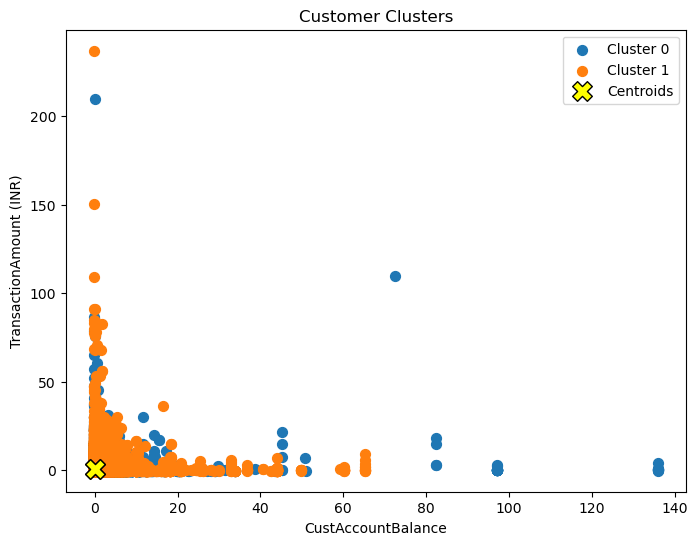

In [42]:
# Choose the two features you want to plot
feature_x = 'CustAccountBalance'
feature_y = 'TransactionAmount (INR)'

plt.figure(figsize=(8, 6))

# Plot each cluster separately
for cluster in data['Cluster'].unique():
    subset = data[data['Cluster'] == cluster]
    plt.scatter(
        subset[feature_x],
        subset[feature_y],
        s=50,
        label=f"Cluster {cluster}"
    )

# Plot centroids (from kmeans model)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    c='yellow',
    marker='X',
    edgecolor='black',
    label='Centroids'
)

plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.legend()
plt.title("Customer Clusters")
plt.show()